In [2]:
# %pip install tensorflow tensorflow-hub

# import tensorflow as tf
# from tensorflow.keras import layers, models, optimizers, callbacks
# from pathlib import Path
# import numpy as np
# import matplotlib.pyplot as plt
# import os

%pip install tensorflow matplotlib scikit-learn

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [3]:
# # Diagnostic: Check what data paths exist
# from pathlib import Path

# PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
# print(f"PROJECT_DIR: {PROJECT_DIR}")
# print(f"\nContents of PROJECT_DIR:")
# for item in PROJECT_DIR.iterdir():
#     print(f"  {item.name}" + (" (dir)" if item.is_dir() else ""))

# # Check for dataset folders
# data_candidates = [
#     PROJECT_DIR / "data" / "classification _dataset",
#     PROJECT_DIR / "data" / "classification _dataset",
#     PROJECT_DIR / "data",
# ]
# print("\nChecking possible dataset locations:")
# for path in data_candidates:
#     exists = path.exists()
#     print(f"  {path}: {exists}")
#     if exists and path.is_dir():
#         try:
#             subdirs = [d.name for d in path.iterdir() if d.is_dir()]
#             print(f"    -> subdirectories: {subdirs}")
#         except:
#             pass
PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "classification_dataset"
MODELS_DIR = PROJECT_DIR / "models" / "custom_cnn"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224,224,3)
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42


In [ ]:
# PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
# DATA_DIR = PROJECT_DIR / "data" / "classification _dataset"
# MODELS_DIR = PROJECT_DIR / "models" / "transfer_learning"
# MODELS_DIR.mkdir(parents=True, exist_ok=True)

# IMG_SIZE = (224,224)
# BATCH_SIZE = 32
# EPOCHS = 25
# NUM_CLASSES = len([d for d in (DATA_DIR/"train").iterdir() if d.is_dir()])
# SEED = 42

# from tensorflow.keras.preprocessing import image_dataset_from_directory
# train_ds = image_dataset_from_directory(DATA_DIR/"train", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
# val_ds = image_dataset_from_directory(DATA_DIR/"valid", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)
# test_ds = image_dataset_from_directory(DATA_DIR/"test", image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

# normalization = tf.keras.layers.Rescaling(1./255)
# train_ds = train_ds.map(lambda x,y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
# val_ds = val_ds.map(lambda x,y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)
# test_ds = test_ds.map(lambda x,y: (normalization(x), y)).cache().prefetch(tf.data.AUTOTUNE)

from tensorflow.keras.preprocessing import image_dataset_from_directory
train_ds = image_dataset_from_directory(DATA_DIR / "train", image_size=IMG_SIZE[:2], batch_size=BATCH_SIZE, seed=SEED)
val_ds = image_dataset_from_directory(DATA_DIR / "valid", image_size=IMG_SIZE[:2], batch_size=BATCH_SIZE, shuffle=False)
test_ds = image_dataset_from_directory(DATA_DIR / "test", image_size=IMG_SIZE[:2], batch_size=BATCH_SIZE, shuffle=False)

# Extract class_names before applying transformations
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x,y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)


Found 700 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Classes: ['bird', 'drone']
Classes: ['bird', 'drone']


In [ ]:
# from tensorflow.keras.applications import EfficientNetB0

# def build_tl_model(img_size=IMG_SIZE+(3,), num_classes=NUM_CLASSES, base_trainable=False):
#     base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=img_size)
#     base_model.trainable = base_trainable
#     inputs = layers.Input(shape=img_size)
#     x = base_model(inputs, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dropout(0.3)(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.4)(x)
#     outputs = layers.Dense(num_classes, activation="softmax")(x)
#     model = models.Model(inputs, outputs)
#     return model

# model_tl = build_tl_model()
# model_tl.summary()

def build_custom_cnn(input_shape=IMG_SIZE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="custom_cnn")
    return model

model = build_custom_cnn()
model.summary()



Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,426 (435.26 KB)

 Trainable params: 110,722 (432.51 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:

LR = 1e-3
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_cb = callbacks.ModelCheckpoint(str(MODELS_DIR/"best_model.h5"), save_best_only=True, monitor="val_accuracy", mode="max")
es_cb = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
csv_logger = callbacks.CSVLogger(str(MODELS_DIR/"training_log.csv"))

print("Model compiled successfully!")
print(f"Learning Rate: {LR}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")


Model compiled successfully!
Learning Rate: 0.001
Batch Size: 32
Epochs: 30


In [34]:
# history_head = model_tl.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=[ckpt, es, reduce_lr])
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, es_cb, reduce_lr, csv_logger]
)

# save history
import pickle
with open(MODELS_DIR/"history.pkl","wb") as f:
    pickle.dump(history.history, f)


Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.9500 - loss: 0.1629

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.9500 - loss: 0.1629 - val_accuracy: 0.5000 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 2/30
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0791 - val_accuracy: 0.5000 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0791 - val_accuracy: 0.5000 - val_loss: 0.6975 - learning_rate: 0.0010
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0440 - val_accuracy: 0.5000 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.5000 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0440 - val_accuracy: 0.5000 - val_loss: 0.6970 - learning_rate: 0.0010
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.5000 - val_loss: 

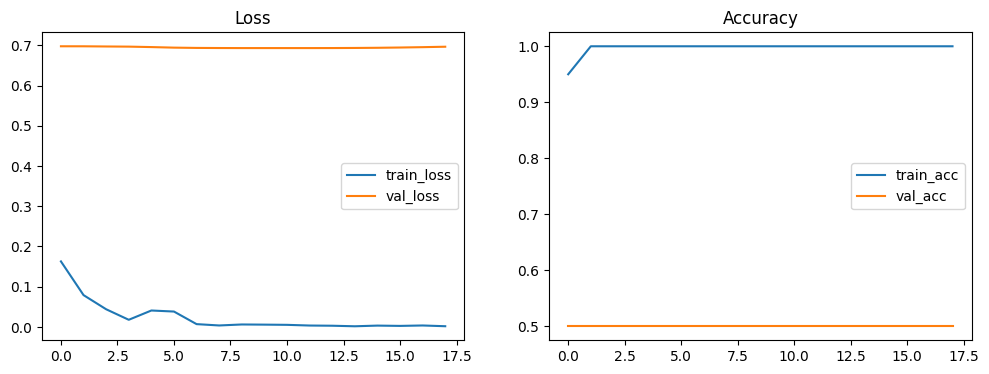

In [35]:
import matplotlib.pyplot as plt
hist = history.history

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step


f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\Aerial Object Classification & Detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

              precision    recall  f1-score   support

        bird       0.50      1.00      0.67         2
       drone       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



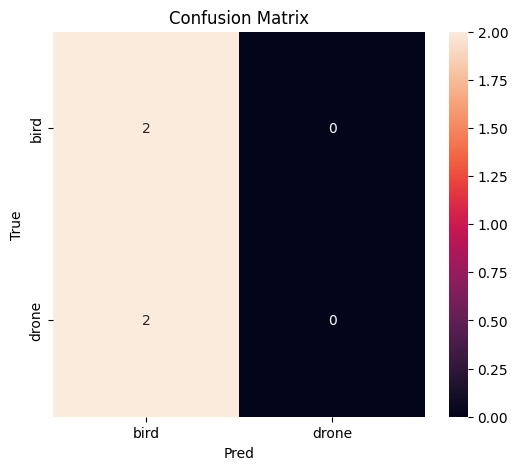

In [36]:
# load best model to be safe
best = tf.keras.models.load_model(MODELS_DIR/"best_model.h5")
y_true = []
y_pred = []

for x_batch, y_batch in test_ds:
    preds = best.predict(x_batch)
    y_true.extend(y_batch.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
with open(MODELS_DIR/"cnn_report.txt","w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Pred"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory
from pathlib import Path
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# PATHS & HYPERPARAMETERS
# -----------------------------
PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "classification_dataset"
MODELS_DIR = PROJECT_DIR / "models" / "custom_cnn_fixed"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)     # height, width
INPUT_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 16           # smaller batch -> more gradient steps
EPOCHS = 30
SEED = 42
LR = 1e-3

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR)

# -----------------------------
# LOAD DATASETS
# -----------------------------
train_ds = image_dataset_from_directory(
    DATA_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
)

val_ds = image_dataset_from_directory(
    DATA_DIR / "valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# Count samples per class in train set
train_counts = {i: 0 for i in range(NUM_CLASSES)}
for batch_x, batch_y in train_ds:
    unique, counts = np.unique(batch_y.numpy(), return_counts=True)
    for u, c in zip(unique, counts):
        train_counts[int(u)] += int(c)

print("Train samples per class:", {class_names[k]: v for k, v in train_counts.items()})

# -----------------------------
# NORMALIZATION + AUGMENTATION
# -----------------------------
normalization_layer = layers.Rescaling(1.0 / 255.0)

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

AUTOTUNE = tf.data.AUTOTUNE

# Augmentation ONLY on train, not on val/test
train_ds = (
    train_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .map(lambda x, y: (data_augmentation(x, training=True), y))
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(lambda x, y: (normalization_layer(x), y))
    .cache()
    .prefetch(AUTOTUNE)
)

# -----------------------------
# MODEL DEFINITION
# -----------------------------
def build_custom_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = models.Model(inputs, outputs, name="custom_cnn_regularized")
    return model

model = build_custom_cnn()
model.summary()

# -----------------------------
# CLASS WEIGHTS (for imbalance)
# -----------------------------
total_train = sum(train_counts.values())
class_weight = {}
for idx, count in train_counts.items():
    if count > 0:
        class_weight[idx] = total_train / (NUM_CLASSES * count)
    else:
        class_weight[idx] = 1.0

print("Class weights:", {class_names[k]: v for k, v in class_weight.items()})

# -----------------------------
# COMPILE
# -----------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=str(MODELS_DIR / "best_model.h5"),
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
)

es_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
)

csv_logger = callbacks.CSVLogger(str(MODELS_DIR / "training_log.csv"))

print("Model compiled successfully!")
print(f"Learning Rate: {LR}")
print(f"Batch Size  : {BATCH_SIZE}")
print(f"Epochs      : {EPOCHS}")

# -----------------------------
# TRAIN
# -----------------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, es_cb, reduce_lr, csv_logger],
    class_weight=class_weight,  # helps with imbalance
)

# -----------------------------
# EVALUATE ON TEST SET
# -----------------------------
print("\nEvaluating on test set:")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}, loss: {test_loss:.4f}")

# -----------------------------
# DETAILED CLASSIFICATION REPORT
# -----------------------------
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    preds = model.predict(batch_x, verbose=0)
    y_true.extend(batch_y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,  # avoids UndefinedMetricWarning
))


PROJECT_DIR: f:\Aerial Object Classification & Detection
DATA_DIR   : f:\Aerial Object Classification & Detection\data\classification_dataset
Found 700 files belonging to 2 classes.
Found 700 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Classes: ['bird', 'drone']
Classes: ['bird', 'drone']
Train samples per class: {'bird': 350, 'drone': 350}
Train samples per class: {'bird': 350, 'drone': 350}


Model: "custom_cnn_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,426 (435.26 KB)

 Trainable params: 110,722 (432.51 KB)

 Non-trainable params: 704 (2.75 KB)

Class weights: {'bird': 1.0, 'drone': 1.0}
Model compiled successfully!
Learning Rate: 0.001
Batch Size  : 16
Epochs      : 30
Epoch 1/30
Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7146 - loss: 0.7842

44/44 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.7429 - loss: 0.6635 - val_accuracy: 0.5000 - val_loss: 0.7349 - learning_rate: 0.0010
Epoch 2/30
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8343 - loss: 0.3976 - val_accuracy: 0.5000 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8343 - loss: 0.3976 - val_accuracy: 0.5000 - val_loss: 0.9162 - learning_rate: 0.0010
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9000 - loss: 0.2709 - val_accuracy: 0.5000 - val_loss: 2.0761 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.9000 - loss: 0.2709 - val_accuracy: 0.5000 - val_loss: 2.0761 - learning_rate: 0.0010
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9008 - loss: 0.2764
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9329 - loss: 0.1964 - val_accuracy: 0